In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx

In [2]:
# loading the network
edges = pd.read_csv('network.csv/edges.csv', comment='#', names=['source', 'target'])
G = nx.Graph()
G = nx.from_pandas_edgelist(edges, source='source', target='target')

In [3]:
# number of nodes
print(G.number_of_nodes())

623766


In [4]:
# number of edges
print(G.number_of_edges())

15699276


In [5]:
# average degree
np.mean([k for n, k in G.degree()])

np.float64(50.33706870845798)

In [6]:
# density
density = nx.density(G)
print(density)

8.069877070444475e-05


In [7]:
# connected components
components = list(nx.connected_components(G))
print(f'number of connected components: {len(components)}')

number of connected components: 8492


In [8]:
# giant component
giant_component = max(components, key=len)

print(f'size of giant component: {len(giant_component)}')

percentage = (len(giant_component) / G.number_of_nodes()) * 100
print(percentage)

size of giant component: 601213
96.38438132248311


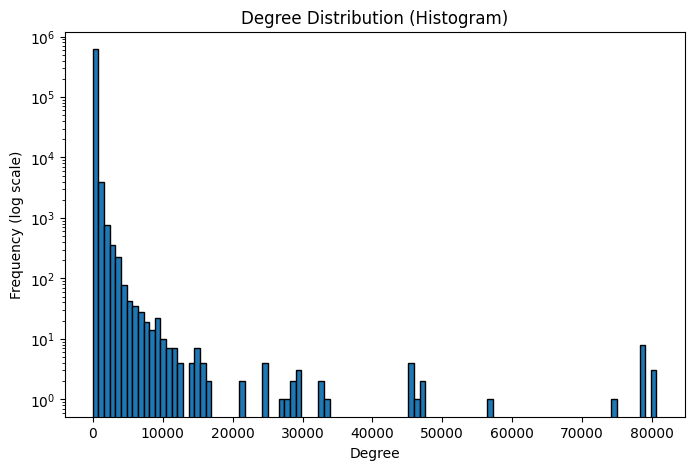

In [9]:
degree_values = [d for _, d in G.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degree_values, bins=100, edgecolor='black', log=True)  # log scale helps large range
plt.xlabel("Degree")
plt.ylabel("Frequency (log scale)")
plt.title("Degree Distribution (Histogram)")
plt.show()

In [10]:
# Store original network metrics
original_metrics = {
    'nodes': G.number_of_nodes(),
    'edges': G.number_of_edges(),
    'density': nx.density(G),
    'avg_degree': np.mean([k for n, k in G.degree()]),
    'num_components': len(list(nx.connected_components(G))),
    'giant_component_size': len(max(nx.connected_components(G), key=len))
}

print("Original Network Metrics:")
for key, value in original_metrics.items():
    print(f"  {key}: {value}")


Original Network Metrics:
  nodes: 623766
  edges: 15699276
  density: 8.069877070444475e-05
  avg_degree: 50.33706870845798
  num_components: 8492
  giant_component_size: 601213


In [11]:
# Randomly remove a percentage of nodes with some randomness
percentage_range = (10, 20)  # remove between 5-10% of nodes
removal_percentage = np.random.uniform(percentage_range[0], percentage_range[1])
num_nodes_to_remove = int(G.number_of_nodes() * removal_percentage / 100)

# Create a copy of the graph
G_modified = G.copy()

# Randomly select nodes to remove
nodes_list = list(G.nodes())
np.random.seed(42)  # for reproducibility
nodes_to_remove = np.random.choice(nodes_list, size=min(num_nodes_to_remove, len(nodes_list)), replace=False)

# Remove the nodes
G_modified.remove_nodes_from(nodes_to_remove)

print(f"Removed {len(nodes_to_remove)} nodes ({removal_percentage:.2f}% of original network)")
print(f"Results saved to 'network_analysis_results.txt'")

# Calculate new network metrics
new_metrics = {
    'nodes': G_modified.number_of_nodes(),
    'edges': G_modified.number_of_edges(),
    'density': nx.density(G_modified),
    'avg_degree': np.mean([k for n, k in G_modified.degree()]) if G_modified.number_of_nodes() > 0 else 0,
    'num_components': len(list(nx.connected_components(G_modified))) if G_modified.number_of_nodes() > 0 else 0,
    'giant_component_size': len(max(nx.connected_components(G_modified), key=len)) if G_modified.number_of_nodes() > 0 else 0
}

# Write results to file
with open('network_analysis_results.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("NETWORK ANALYSIS: NODE REMOVAL IMPACT\n")
    f.write("=" * 60 + "\n\n")
    
    f.write(f"Removed {len(nodes_to_remove)} nodes ({removal_percentage:.2f}% of original network)\n\n")
    
    f.write("Original Network Metrics:\n")
    for key, value in original_metrics.items():
        f.write(f"  {key}: {value}\n")
    
    f.write("\nModified Network Metrics:\n")
    for key, value in new_metrics.items():
        f.write(f"  {key}: {value}\n")
    
    f.write("\nNetwork Changes:\n")
    f.write(f"  Node reduction: {original_metrics['nodes'] - new_metrics['nodes']} ({((original_metrics['nodes'] - new_metrics['nodes']) / original_metrics['nodes'] * 100):.2f}%)\n")
    f.write(f"  Edge reduction: {original_metrics['edges'] - new_metrics['edges']} ({((original_metrics['edges'] - new_metrics['edges']) / original_metrics['edges'] * 100):.2f}%)\n")
    f.write(f"  Density change: {new_metrics['density'] - original_metrics['density']:.4f}\n")
    f.write(f"  Avg degree change: {new_metrics['avg_degree'] - original_metrics['avg_degree']:.4f}\n")
    f.write(f"  Component count change: {new_metrics['num_components'] - original_metrics['num_components']}\n")
    f.write(f"  Giant component reduction: {original_metrics['giant_component_size'] - new_metrics['giant_component_size']} nodes\n")


Removed 82407 nodes (13.21% of original network)
Results saved to 'network_analysis_results.txt'


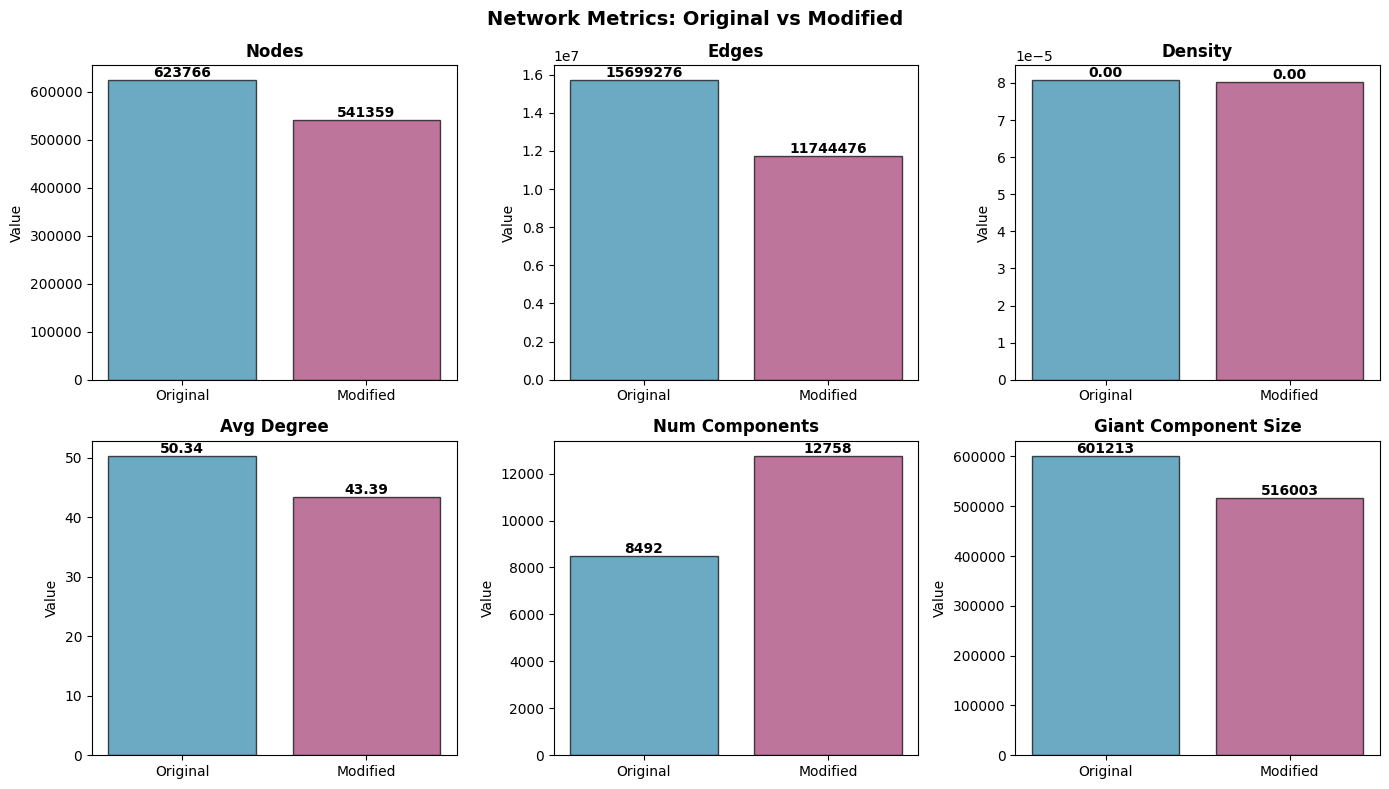

In [12]:
# Visualize comparison of metrics
metrics_comparison = pd.DataFrame({
    'Original': original_metrics,
    'Modified': new_metrics
})

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Network Metrics: Original vs Modified', fontsize=14, fontweight='bold')

# Select numeric metrics for visualization
viz_metrics = ['nodes', 'edges', 'density', 'avg_degree', 'num_components', 'giant_component_size']

for idx, metric in enumerate(viz_metrics):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    values = [original_metrics[metric], new_metrics[metric]]
    labels = ['Original', 'Modified']
    colors = ['#2E86AB', '#A23B72']
    
    ax.bar(labels, values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(metric.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Value')
    
    # Add value labels on bars
    for i, v in enumerate(values):
        ax.text(i, v, f'{v:.2f}' if isinstance(v, float) else f'{int(v)}', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
